# Linear real first-order reciprocity test

Goal: check the linear part of Theorem 6.1 for real first-order systems $\dot u+Ku=f$. The notebook runs the forward system, then runs the adjoint with $K$, as the hardware would, and with $K^T$, as an exact digital reference, and builds gradients from both. Taylor tests on a reciprocal case ($\rho=0$) and a nonreciprocal case ($\rho\ne0$) show that the hardware gradient is correct only when $\rho=0$.

The theorem says that a linear first-order system can compute its trajectory adjoint on the same physical hardware when the linear operator is reciprocal:

$$
K(t)^T=K(t).
$$

The forward dynamics are

$$
\dot u(t)+K(t;p_K)u(t)-f(t;p_f)=0,
\qquad
u(0)=u_0(p_0).
$$

We use a two-mode overdamped system with explicit time dependence,

$$
K(t)=
\begin{pmatrix}
k_0+k_c+\alpha\cos(\Omega t)&-k_c+\beta\sin(\Omega t)+\rho\\
-k_c+\beta\sin(\Omega t)-\rho&k_1+k_c-\alpha\cos(\Omega t)
\end{pmatrix}.
$$

The scalar parameter $\rho$ breaks reciprocity. If $\rho=0$, then $K(t)^T=K(t)$ for every $t$. The drive and initial condition are also parameterized, so the Taylor test checks initial-condition, operator, and source gradients in one vector.

The cost is

$$
\chi
=\int_0^T \frac{q}{2}\|u(t)-r(t)\|^2\,dt
+\frac{q_T}{2}\|u(T)-u_*\|^2.
$$

Using reverse adjoint time $\tau=T-t$, the exact digital adjoint satisfies

$$
\dot a(\tau)
+K(T-\tau)^T a(\tau)
+\theta_u[u(T-\tau),T-\tau]=0,
$$

with initial condition

$$
a(0)=-\psi_u[u(T)].
$$

The physical adjoint run uses the same hardware operator instead:

$$
\dot a_{phys}(\tau)
+K(T-\tau)a_{phys}(\tau)
+\theta_u[u(T-\tau),T-\tau]=0.
$$

Therefore $a_{phys}=a$ only in the reciprocal case. The gradient overlap is

$$
\frac{d\chi}{dp}
=
\int_0^T
 a(T-t)^T
\left[K_p(t)u(t)-f_p(t)\right]dt,
$$

and the initial-condition boundary term is

$$
\frac{d\chi}{du_0}=-a(T).
$$

The Taylor tests below compare a reciprocal case, $\rho=0$, with a nonreciprocal case, $\rho\ne0$. The digital adjoint should pass in both cases. The physical adjoint should pass only in the reciprocal case.


### Setup
Imports, time grid, integrator tolerances, parameter labels (initial condition, operator, drive), and cost weights.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

T = 6.0
Nt = 1001
rtol = 1e-10
atol = 1e-12

t_grid = np.linspace(0.0, T, Nt)

initial_condition_names = ["u0[0]", "u0[1]"]
matrix_parameter_names = ["k0", "k1", "kc", "rho", "alpha", "beta", "Omega"]
drive_parameter_names = ["A0", "A1", "omega_f", "decay"]
parameter_names = initial_condition_names + matrix_parameter_names + drive_parameter_names

q_traj = 0.20
q_T = 0.80
u_target = np.array([0.08, -0.05])

np.set_printoptions(precision=6, suppress=False)


### Operator, drive, and their parameter derivatives
$K(t)$ has a symmetric part (on-site $k_0,k_1$, coupling $k_c$, modulations $\alpha,\beta$) plus the antisymmetric term $\rho$, which is the only thing that breaks reciprocity. The drive has a decaying envelope so the `decay` parameter is also tested. `dK_dp` and `drive_dp` supply $K_p$ and $f_p$ for the overlap integrals.

In [2]:
def make_parameters(rho):
    return np.array(
        [0.45, -0.25]
        + [1.20, 1.70, 0.35, rho, 0.18, 0.10, 0.90]
        + [0.18, -0.11, 1.10, 0.08],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_condition(p):
    p = unpack(p)
    return np.array([p["u0[0]"], p["u0[1]"]], dtype=float)


def K(t, p):
    p = unpack(p)
    ct = np.cos(p["Omega"] * t)
    st = np.sin(p["Omega"] * t)
    return np.array(
        [
            [p["k0"] + p["kc"] + p["alpha"] * ct, -p["kc"] + p["beta"] * st + p["rho"]],
            [-p["kc"] + p["beta"] * st - p["rho"], p["k1"] + p["kc"] - p["alpha"] * ct],
        ],
        dtype=float,
    )


def dK_dp(t, p, name):
    p_dict = unpack(p)
    ct = np.cos(p_dict["Omega"] * t)
    st = np.sin(p_dict["Omega"] * t)
    if name == "k0":
        return np.array([[1.0, 0.0], [0.0, 0.0]])
    if name == "k1":
        return np.array([[0.0, 0.0], [0.0, 1.0]])
    if name == "kc":
        return np.array([[1.0, -1.0], [-1.0, 1.0]])
    if name == "rho":
        return np.array([[0.0, 1.0], [-1.0, 0.0]])
    if name == "alpha":
        return np.array([[ct, 0.0], [0.0, -ct]])
    if name == "beta":
        return np.array([[0.0, st], [st, 0.0]])
    if name == "Omega":
        dct = -t * np.sin(p_dict["Omega"] * t)
        dst = t * np.cos(p_dict["Omega"] * t)
        return np.array(
            [
                [p_dict["alpha"] * dct, p_dict["beta"] * dst],
                [p_dict["beta"] * dst, -p_dict["alpha"] * dct],
            ]
        )
    raise KeyError(name)


def drive(t, p):
    p = unpack(p)
    envelope = np.exp(-p["decay"] * t)
    wt = p["omega_f"] * t
    return envelope * np.array([p["A0"] * np.sin(wt), p["A1"] * np.cos(wt)], dtype=float)


def drive_dp(t, p, name):
    p_dict = unpack(p)
    envelope = np.exp(-p_dict["decay"] * t)
    wt = p_dict["omega_f"] * t
    if name == "A0":
        return envelope * np.array([np.sin(wt), 0.0])
    if name == "A1":
        return envelope * np.array([0.0, np.cos(wt)])
    if name == "omega_f":
        return envelope * np.array([
            p_dict["A0"] * t * np.cos(wt),
            -p_dict["A1"] * t * np.sin(wt),
        ])
    if name == "decay":
        return -t * drive(t, p)
    raise KeyError(name)


### Cost and forward solve
The cost has a running tracking term $\theta$ and a terminal term $\psi$, each with its gradient in $u$. The forward model integrates $\dot u=f-Ku$ and stores a dense interpolant so the adjoint can query $u(T-\tau)$.

In [3]:
def u_reference(t):
    return np.array([0.05 * np.sin(0.50 * t), -0.03 * np.cos(0.70 * t)], dtype=float)


def theta_value(u, t):
    return 0.5 * q_traj * np.sum((u - u_reference(t)) ** 2)


def theta_u(u, t):
    return q_traj * (u - u_reference(t))


def psi_value(u):
    return 0.5 * q_T * np.sum((u - u_target) ** 2)


def psi_u(u):
    return q_T * (u - u_target)


def forward_rhs(t, u, p):
    return drive(t, p) - K(t, p) @ u


def solve_forward(p):
    sol = solve_ivp(
        lambda t, u: forward_rhs(t, u, p),
        (0.0, T),
        initial_condition(p),
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def objective(p):
    sol = solve_forward(p)
    values = [theta_value(sol.y[:, k], sol.t[k]) for k in range(sol.t.size)]
    return simpson(values, x=sol.t) + psi_value(sol.y[:, -1])


### Adjoint solvers, gradient, and diagnostics
Both adjoints run in reverse time $\tau=T-t$ from $a(0)=-\psi_u(u(T))$:
- `solve_digital_adjoint` uses $K(T-\tau)^T$, the exact adjoint.
- `solve_physical_adjoint` uses $K(T-\tau)$, which is what the same hardware produces.

`gradient_from_adjoint` returns $-a(T)$ for the initial condition and the overlap integrals for $p_K$ and $p_f$. The helpers measure:
- the reciprocity defect, as a maximum over sampled times because $K$ depends on $t$;
- the relative $L^2$ difference between the two adjoint fields.

In [4]:
def solve_digital_adjoint(p, forward):
    a0 = -psi_u(forward.y[:, -1])

    def rhs(tau, a):
        t_forward = T - tau
        return -K(t_forward, p).T @ a - theta_u(forward.sol(t_forward), t_forward)

    sol = solve_ivp(
        rhs,
        (0.0, T),
        a0,
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def solve_physical_adjoint(p, forward):
    a0 = -psi_u(forward.y[:, -1])

    def rhs(tau, a):
        t_forward = T - tau
        return -K(t_forward, p) @ a - theta_u(forward.sol(t_forward), t_forward)

    sol = solve_ivp(
        rhs,
        (0.0, T),
        a0,
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def gradient_from_adjoint(p, forward, adjoint):
    gradient = list(-adjoint.sol(T))

    for name in matrix_parameter_names:
        values = []
        for t in t_grid:
            u = forward.sol(t)
            a = adjoint.sol(T - t)
            values.append(a @ (dK_dp(t, p, name) @ u))
        gradient.append(simpson(values, x=t_grid))

    for name in drive_parameter_names:
        values = []
        for t in t_grid:
            a = adjoint.sol(T - t)
            values.append(a @ (-drive_dp(t, p, name)))
        gradient.append(simpson(values, x=t_grid))

    return np.array(gradient, dtype=float)


def taylor_errors(p, gradients, h_values, direction):
    chi0 = objective(p)
    p_scale = np.mean(np.abs(p))
    errors = {}
    for label, gradient in gradients.items():
        errors[label] = np.array([
            abs(objective(p + h * p_scale * direction) - chi0 - gradient @ (h * p_scale * direction))
            for h in h_values
        ])
    return errors


def reciprocity_defect(p):
    return max(np.linalg.norm(K(t, p) - K(t, p).T) for t in t_grid[::25])


def adjoint_field_error(digital, physical):
    numerator = simpson(np.sum((digital.y - physical.y) ** 2, axis=0), x=t_grid)
    denominator = simpson(np.sum(digital.y ** 2, axis=0), x=t_grid)
    return np.sqrt(numerator / denominator)


### Run both cases
In the reciprocal case the two adjoint ODEs are identical, so the field and gradient differences are exactly zero. In the nonreciprocal case they differ at order one.

In [5]:
def solve_case(label, rho):
    p = make_parameters(rho=rho)
    forward = solve_forward(p)
    digital = solve_digital_adjoint(p, forward)
    physical = solve_physical_adjoint(p, forward)
    grad_digital = gradient_from_adjoint(p, forward, digital)
    grad_physical = gradient_from_adjoint(p, forward, physical)
    return {
        "label": label,
        "p": p,
        "forward": forward,
        "digital": digital,
        "physical": physical,
        "grad_digital": grad_digital,
        "grad_physical": grad_physical,
    }


cases = [
    solve_case("reciprocal", rho=0.0),
    solve_case("nonreciprocal", rho=0.35),
]

for result in cases:
    p = result["p"]
    rel_field_error = adjoint_field_error(result["digital"], result["physical"])
    rel_grad_error = np.linalg.norm(result["grad_physical"] - result["grad_digital"]) / np.linalg.norm(result["grad_digital"])
    print(f"{result['label']} case")
    print(f"  rho={unpack(p)['rho']:.2f}")
    print(f"  max_t ||K(t)-K(t).T||: {reciprocity_defect(p):.3e}")
    print(f"  relative physical/digital field error: {rel_field_error:.3e}")
    print(f"  relative physical/digital gradient error: {rel_grad_error:.3e}")
    print()


reciprocal case
  rho=0.00
  max_t ||K(t)-K(t).T||: 0.000e+00
  relative physical/digital field error: 0.000e+00
  relative physical/digital gradient error: 0.000e+00

nonreciprocal case
  rho=0.35
  max_t ||K(t)-K(t).T||: 9.899e-01
  relative physical/digital field error: 2.669e-01
  relative physical/digital gradient error: 1.602e-01



### Taylor test of the physical adjoint
Expected result: $h^2$ slope for $\rho=0$ and $h$ slope for $\rho=0.35$.

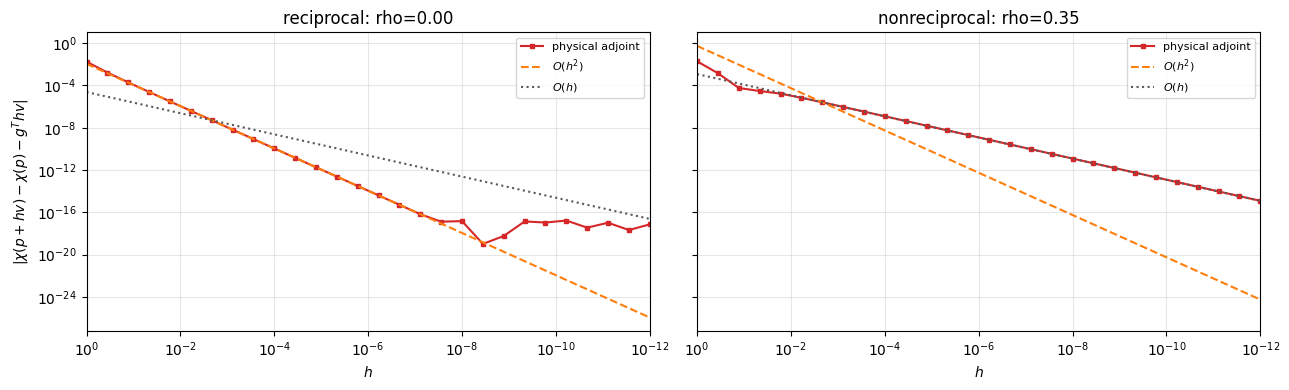

In [6]:
rng = np.random.default_rng(6)
direction = rng.normal(size=len(parameter_names))
direction = direction / np.linalg.norm(direction)
h_values = np.logspace(0, -12, 28)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"physical adjoint": result["grad_physical"]},
        h_values,
        direction,
    )
    anchor = 6
    ref2 = errors["physical adjoint"][anchor] * (h_values / h_values[anchor]) ** 2
    ref1 = errors["physical adjoint"][anchor] * (h_values / h_values[anchor])

    ax.loglog(h_values, errors["physical adjoint"], "s-", ms=3, color="tab:red", label="physical adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, ref1, ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{result['label']}: rho={unpack(result['p'])['rho']:.2f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()


### Control: Taylor test of the digital adjoint
The exact adjoint should give an $h^2$ slope in both cases.

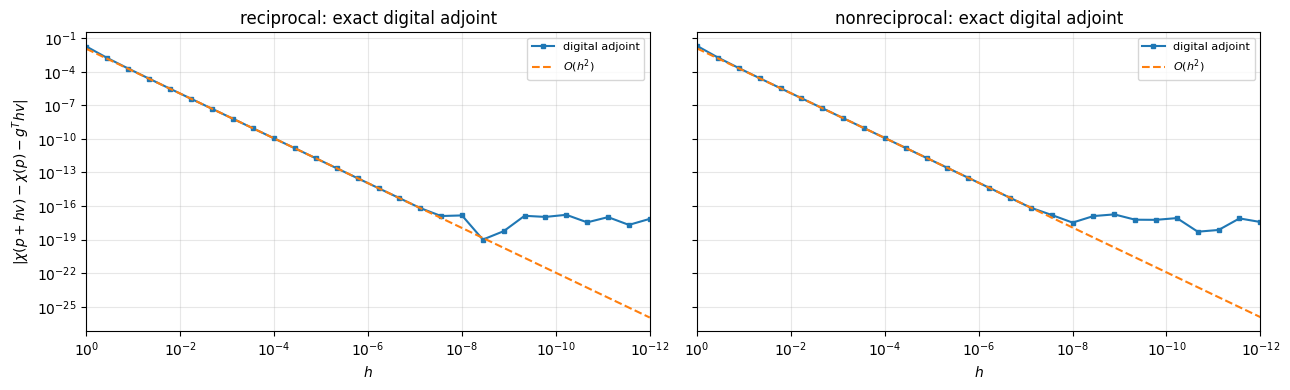

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"digital adjoint": result["grad_digital"]},
        h_values,
        direction,
    )
    anchor = 6
    ref2 = errors["digital adjoint"][anchor] * (h_values / h_values[anchor]) ** 2

    ax.loglog(h_values, errors["digital adjoint"], "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{result['label']}: exact digital adjoint")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()
